In [1]:
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
import os
import numpy as np
import keras
from keras.layers import Dense, Conv2D, BatchNormalization, Activation
from keras.layers import AveragePooling2D, Input, Flatten
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2
from keras import backend as K
from keras.models import Model

def load_and_preprocess_data(csv_path, image_base_path, angles_to_process=None):
    # Load the metadata CSV
    df = pd.read_csv(csv_path)
    angle_groups = df.groupby('cam_angle')
    
    # If angles_to_process is not specified, process all angles
    if angles_to_process is None:
        angles_to_process = angle_groups.groups.keys()
    else:
        angles_to_process = [angles_to_process] if isinstance(angles_to_process, (int, float)) else angles_to_process
    
    X_all, y_all = [], []
    
    # Iterate through each angle and process
    for angle in angles_to_process:
        if angle not in angle_groups.groups:
            print(f"Angle {angle} not found in the dataset. Skipping.")
            continue
        print(f"Processing angle: {angle}")
        group = angle_groups.get_group(angle)
        
        for _, row in group.iterrows():
            image_path = os.path.join(image_base_path, row['image_filename'])
            try:
                img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (240, 240))
                    img = img.astype('float32') / 255.0  # Normalize to [0, 1]
                    X_all.append(img)
                    y_all.append(row['label'])
                else:
                    print(f"Failed to load image: {image_path}")
            except Exception as e:
                print(f"Error processing image {image_path}: {str(e)}")
    
    if not X_all:
        raise ValueError("No valid images found in the dataset.")
    
    X_all = np.array(X_all)
    y_all = np.array(y_all)
    
    # Use LabelEncoder to ensure labels are zero-indexed
    label_encoder = LabelEncoder()
    y_all = label_encoder.fit_transform(y_all)
    
    # Split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
    

    X_train = X_train.reshape(-1, 240, 240, 1)
    X_test = X_test.reshape(-1, 240, 240, 1)
    
    # Get the number of unique classes
    num_classes = len(label_encoder.classes_)
    
    return (X_train, y_train), (X_test, y_test), num_classes

def load_data():
    # Define the paths
    csv_path = '/kaggle/input/msi-processed-dataset/msi_metadata.csv'
    image_base_path = '/kaggle/input/msi-processed-dataset/msi_images'
    
    # Specify the angles to process
    angles_to_process = [0, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180]
    
    # Load and preprocess the data
    return load_and_preprocess_data(csv_path, image_base_path, angles_to_process)

# Usage example:
(X_train, y_train), (X_test, y_test), num_classes = load_data()

# Print summary of the loaded data
print("\nSummary of loaded data:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Image shape: {X_train.shape[1:]}")
print(f"Number of classes: {num_classes}")

# Data Preprocessing
subtract_pixel_mean = True

# If subtract pixel mean is enabled
if subtract_pixel_mean:
    x_train_mean = np.mean(X_train, axis=0)
    X_train -= x_train_mean
    X_test -= x_train_mean

# Convert class vectors to binary class matrices.
y_train = keras.utils.to_categorical(y_train, num_classes) 
y_test = keras.utils.to_categorical(y_test, num_classes)

# Print shapes after preprocessing
print("\nAfter preprocessing:")
print('X_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')
print('y_train shape:', y_train.shape)

Processing angle: 0
Processing angle: 18
Processing angle: 36
Processing angle: 54
Processing angle: 72
Processing angle: 90
Processing angle: 108
Processing angle: 126
Processing angle: 144
Processing angle: 162
Processing angle: 180

Summary of loaded data:
Training samples: 6523
Testing samples: 1631
Image shape: (240, 240, 1)
Number of classes: 124

After preprocessing:
X_train shape: (6523, 240, 240, 1)
6523 train samples
1631 test samples
y_train shape: (6523, 124)


/opt/conda/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1728756910.064435     102 service.cc:145] XLA service 0x7e3184127850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728756910.064490     102 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1728756910.064495     102 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1728757007.934678     102 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_slice_fusion_3', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1728757008.121

186/204 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.0122 - loss: 5.2342

I0000 00:00:1728757160.553622     104 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_slice_fusion_3', 12 bytes spill stores, 12 bytes spill loads



204/204 ━━━━━━━━━━━━━━━━━━━━ 340s 900ms/step - accuracy: 0.0126 - loss: 5.2233 - val_accuracy: 0.0061 - val_loss: 5.0080
Epoch 2/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 72s 347ms/step - accuracy: 0.0371 - loss: 4.7318 - val_accuracy: 0.0098 - val_loss: 5.8034
Epoch 3/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 71s 345ms/step - accuracy: 0.0642 - loss: 4.3634 - val_accuracy: 0.0092 - val_loss: 7.1149
Epoch 4/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 71s 345ms/step - accuracy: 0.1263 - loss: 3.8162 - val_accuracy: 0.0123 - val_loss: 7.5851
Epoch 5/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 72s 346ms/step - accuracy: 0.2005 - loss: 3.3553 - val_accuracy: 0.2121 - val_loss: 3.1964
Epoch 6/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 71s 345ms/step - accuracy: 0.2545 - loss: 3.0046 - val_accuracy: 0.3299 - val_loss: 2.6819
Epoch 7/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 71s 345ms/step - accuracy: 0.3327 - loss: 2.6877 - val_accuracy: 0.2544 - val_loss: 2.8318
Epoch 8/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 71s 344ms/step - accuracy: 0.3866 - loss: 2.4188 - va

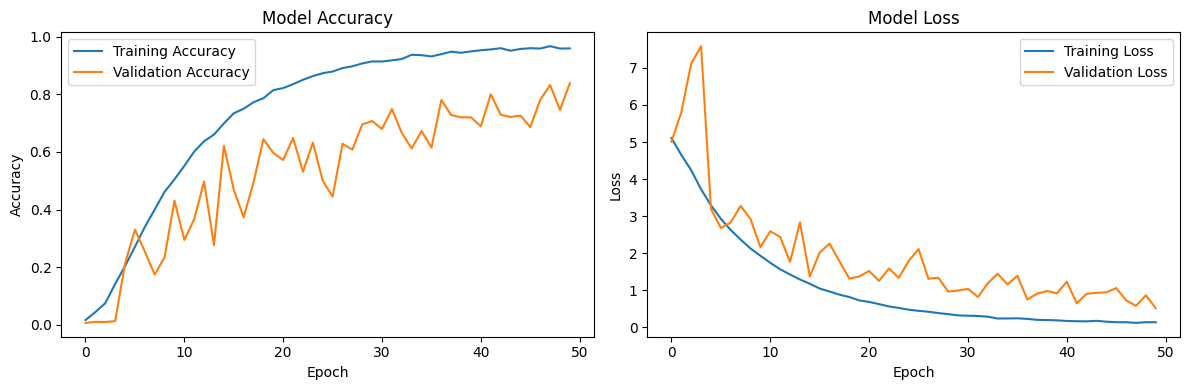

In [2]:
#DenseNet 2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np

def dense_block(x, blocks, name):
    for i in range(blocks):
        x = conv_block(x, 32, name=name + '_block' + str(i + 1))
    return x

def transition_block(x, reduction, name):
    bn_axis = 3
    x = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name=name + '_bn')(x)
    x = layers.Activation('relu', name=name + '_relu')(x)
    x = layers.Conv2D(int(tf.keras.backend.int_shape(x)[bn_axis] * reduction), 1, use_bias=False, name=name + '_conv')(x)
    x = layers.AveragePooling2D(2, strides=2, name=name + '_pool')(x)
    return x

def conv_block(x, growth_rate, name):
    bn_axis = 3
    x1 = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name=name + '_0_bn')(x)
    x1 = layers.Activation('relu', name=name + '_0_relu')(x1)
    x1 = layers.Conv2D(4 * growth_rate, 1, use_bias=False, name=name + '_1_conv')(x1)
    x1 = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name=name + '_1_bn')(x1)
    x1 = layers.Activation('relu', name=name + '_1_relu')(x1)
    x1 = layers.Conv2D(growth_rate, 3, padding='same', use_bias=False, name=name + '_2_conv')(x1)
    x = layers.Concatenate(axis=bn_axis, name=name + '_concat')([x, x1])
    return x

def GaitDenseNet(input_shape=(128, 128, 1), num_classes=124):
    inputs = keras.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(inputs)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name='conv1_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = layers.MaxPooling2D(3, strides=2, name='pool1')(x)

    # Dense blocks
    x = dense_block(x, 6, name='conv2')
    x = transition_block(x, 0.5, name='pool2')
    x = dense_block(x, 12, name='conv3')
    x = transition_block(x, 0.5, name='pool3')
    x = dense_block(x, 24, name='conv4')
    x = transition_block(x, 0.5, name='pool4')
    x = dense_block(x, 16, name='conv5')

    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name='bn')(x)
    x = layers.Activation('relu', name='relu')(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)

    # Fully connected layers (MLP part)
    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='fc1_bn')(x)
    x = layers.LeakyReLU(alpha=0.1, name='fc1_leakyrelu')(x)
    x = layers.Dropout(0.3, name='fc1_dropout')(x)

    x = layers.Dense(512, name='fc2')(x)
    x = layers.BatchNormalization(name='fc2_bn')(x)
    x = layers.LeakyReLU(alpha=0.1, name='fc2_leakyrelu')(x)
    x = layers.Dropout(0.3, name='fc2_dropout')(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='gait-densenet')
    return model

def compile_and_train(model, X_train, y_train, X_test, y_test, epochs=50, batch_size=32):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Data augmentation
    datagen = keras.preprocessing.image.ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        vertical_flip=False
    )

    # Prepare the training dataset
    train_generator = datagen.flow(X_train, y_train, batch_size=batch_size)

    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True
    )

    # Train the model
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Calculate entropy loss
    y_pred = model.predict(X_test)
    entropy_loss = -np.sum(y_test * np.log(y_pred + 1e-9)) / len(y_test)

    return test_accuracy, entropy_loss, history

# Usage example
input_shape = (240, 240, 1)  # Adjust based on your actual input shape
num_classes = 124  # Adjust based on your actual number of classes

# Create the model
model = GaitDenseNet(input_shape=input_shape, num_classes=num_classes)

# Compile and train the model
accuracy, entropy_loss, history = compile_and_train(model, X_train, y_train, X_test, y_test)

print(f"Final Test Accuracy: {accuracy}")
print(f"Final Entropy Loss: {entropy_loss}")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()